## Import Library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from imblearn.over_sampling import SMOTE

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn import under_sampling, over_sampling
from imblearn import over_sampling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

## Load dataset

In [ ]:
df = pd.read_csv('/content/1702184567307-WA_FnUseC_TelcoCustomerChurn (1).csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Split Dataset

In [ ]:
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn'].map({'Yes':1,'No':0})

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((5634, 19), (1409, 19))

## Train

## EDA

In [ ]:
# Description of dataset
X_train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5634.000000
mean,0.160809,32.373092,64.864253
std,0.367388,24.424539,30.089324
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.525000
75%,0.000000,55.000000,89.937500
max,1.000000,72.000000,118.600000


In [ ]:
# missing value
X_train.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


There is no missing value in this x train dataset

In [ ]:
# Detail of Chrun column (target)
y_train.value_counts()

,count
Churn,
0,4138
1,1496


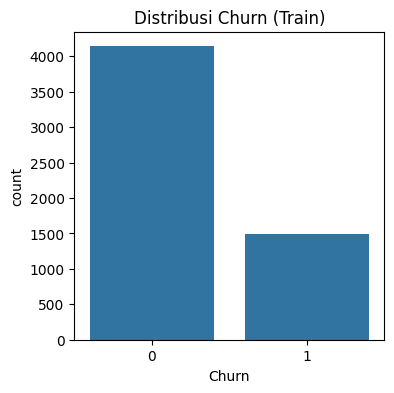

In [ ]:
# Visualization of churn column (target)
plt.figure(figsize=(4,4))
sns.countplot(x=y_train)
plt.title('Distribusi Churn (Train)')
plt.show()

In [ ]:
# Seperate numeric column and categorical column by data type
numeric_columns = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_columns = X_train.select_dtypes(include=['object','bool']).columns.tolist()

numeric_columns, categorical_columns

(['SeniorCitizen', 'tenure', 'MonthlyCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'TotalCharges'])

### Data Preprocessing

In [ ]:
# change data type of Total charge object -> numeric (X_train)
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
X_train['TotalCharges'].fillna(X_train['TotalCharges'].median(), inplace=True)

In [ ]:
# Categorical encoding
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 17

In [ ]:
# Select columns whose data type is not numeric
column_non_numeric = X_train.select_dtypes(exclude=['number']).columns.tolist()
column_non_numeric

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [ ]:
# Label Encoding
gender_encoder = LabelEncoder()
partner_encoder = LabelEncoder()
dependents_encoder = LabelEncoder()
phoneservice_encoder = LabelEncoder()
multiplelines_encoder = LabelEncoder()
internetservice_encoder = LabelEncoder()
onlinesecurity_encoder = LabelEncoder()
onlinebackup_encoder = LabelEncoder()
deviceprotection_encoder = LabelEncoder()
techsupport_encoder = LabelEncoder()
streamingtv_encoder = LabelEncoder()
streamingmovies_encoder = LabelEncoder()
contract_encoder = LabelEncoder()
paperlessbilling_encoder = LabelEncoder()
paymentmethod_encoder = LabelEncoder()

In [ ]:
X_train['gender'] = gender_encoder.fit_transform(X_train['gender'])
X_train['Partner'] = partner_encoder.fit_transform(X_train['Partner'])
X_train['Dependents'] = dependents_encoder.fit_transform(X_train['Dependents'])
X_train['PhoneService'] = phoneservice_encoder.fit_transform(X_train['PhoneService'])
X_train['MultipleLines'] = multiplelines_encoder.fit_transform(X_train['MultipleLines'])
X_train['InternetService'] = internetservice_encoder.fit_transform(X_train['InternetService'])
X_train['OnlineSecurity'] = onlinesecurity_encoder.fit_transform(X_train['OnlineSecurity'])
X_train['OnlineBackup'] = onlinebackup_encoder.fit_transform(X_train['OnlineBackup'])
X_train['DeviceProtection'] = deviceprotection_encoder.fit_transform(X_train['DeviceProtection'])
X_train['TechSupport'] = techsupport_encoder.fit_transform(X_train['TechSupport'])
X_train['StreamingTV'] = streamingtv_encoder.fit_transform(X_train['StreamingTV'])
X_train['StreamingMovies'] = streamingmovies_encoder.fit_transform(X_train['StreamingMovies'])
X_train['Contract'] = contract_encoder.fit_transform(X_train['Contract'])
X_train['PaperlessBilling'] = paperlessbilling_encoder.fit_transform(X_train['PaperlessBilling'])
X_train['PaymentMethod'] = paymentmethod_encoder.fit_transform(X_train['PaymentMethod'])

In [ ]:
# Imbalance handling
# Oversampling

X_over_smote, y_over_smote = over_sampling.SMOTE(random_state=42).fit_resample(X_train, y_train)

In [ ]:
# Scaling
scaler = StandardScaler()
scaler.fit(X_over_smote)
X_std = scaler.transform(X_over_smote)

### Modeling (Gunakan lebih min 2 model dan bandingkan hasil evaluasinya)

In [ ]:
# Randon Forest (Cross-validation)
model = RandomForestClassifier()

cv_scores = cross_val_score(model, X_std, y_over_smote, cv=5, scoring='f1')

print("F1-score pe fold:", cv_scores)
print("F1-score rata-rata:", cv_scores.mean())
print("F1-score std     :", cv_scores.std())

F1-score pe fold: [0.68061367 0.74004051 0.90754396 0.90123457 0.90406321]
F1-score rata-rata: 0.8266991827415019
F1-score std     : 0.09687857981163937


Berdasarkan hasil dari Cross Validation didapatkan hasil F 1 dan 2 rendah yaitu 0.68 dan 0.74 yang berarti kurang baik sedangkan fold 3 - 5 memiliki kisaran diatas 0.90 yang menandakan model sangat baik dalam mendeteksi churn.

F1 score rata-rata dari model cross validation ini cukup baik yaitu 0.8292 sehingga secara keseluruhan performa model dalam menangkan churn dengan baik

Namun berdasarkan data standar deviasi yang cukup tinggi yaitu 0.095 menunjukan stabilitas antar fold yang kurang stabil, hal ini dapat terjadi dikarenakan terdapat kesenjangan data yang sangat tinggi antara fold 1 dan 5

In [ ]:
# Random Forest (KFold)
model = RandomForestClassifier()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = []
recall_scores = []
precision_scores = []

for train_index, test_index in kf.split(X_std):

    X_train_kf, X_val_kf = X_std[train_index], X_std[test_index]
    y_train_kf, y_val_kf = y_over_smote.values[train_index], y_over_smote.values[test_index]

    model.fit(X_train_kf, y_train_kf)
    y_pred = model.predict(X_val_kf)

    f1_scores.append(f1_score(y_val_kf, y_pred))
    recall_scores.append(recall_score(y_val_kf, y_pred))
    precision_scores.append(precision_score(y_val_kf, y_pred))

f1_mean, f1_std = np.mean(f1_scores), np.std(f1_scores)
recall_mean, recall_std = np.mean(recall_scores), np.std(recall_scores)
precision_mean, precision_std = np.mean(precision_scores), np.std(precision_scores)

print("F1 mean/std:", f1_mean, f1_std)
print("Recall mean/std:", recall_mean, recall_std)
print("Precision mean/std:", precision_mean, precision_std)

F1 mean/std: 0.8531778819625098 0.005949022120606516
Recall mean/std: 0.8569869580124705 0.006550342271704967
Precision mean/std: 0.8495114586004073 0.011082975664151565


Berdasarkan hasil model KFold didepatkan rata F1 score yaitu 0.84947 yang mana menandakan model memiliki performa yang baik dalam mendeteksi pelanggan churn.

Dari model didapatkan std yang sangat kecil yaitu 0.00675 yang mana sangat kecil, oleh sebab itu model ini sangat stabil

Berdasarkan hasil didapatkan recall mean sebesar 0.85144 yang bermakna model dapat menemukan 85% pelanggan yang benar-benar churn.
serta std pada recal sangat stabil yaitu 0.00919

Berdasarkan hasil precision mean didapatkan sebesar 0.84764 yang bermakna model ini dapat melakukan prediksi churn dengan akurat sebesar 84% dengan std yang  tergolong stabil

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

cv_scores = cross_val_score(dt_model, X_std, y_over_smote, cv=5, scoring='f1')

print("F1-score per fold:", cv_scores)
print("F1-score rata-rata:", cv_scores.mean())

F1-score per fold: [0.64060357 0.67972973 0.83295455 0.8458498  0.85199775]
F1-score rata-rata: 0.7702270786201006


Berdasarkan hasil model decision tree dapat dilihat bahwa performanya kurang stabil dikarenakan terdapat variasi data fold 1 dan 2 di rentang 0.6 yang tergolong rendah sedangkan 3, 4 dan 5 tergolong baik dikisaran 0.8.

Berdasarkan rata-rata F1 score dapat dilihat bahwa F1 score 0.77 yang cukup baik, namun jika dibandingkan dengan perr=forma random forest, masih lebih baik random forest

### Evaluation

Berdasarkan ketiga model tersebut, model terbaik adalah Random Forest (K-Fold). Hal ini dikarenakan model K-fold menghasilkan F1-score tertinggi (0.849) dengan standar deviasi terendah, menunjukkan performa yang akurat dan stabil. Precision dan recall yang seimbang juga menjadikan Random Forest lebih dapat diandalkan dibanding Decision Tree yang performanya lebih fluktuatif di tiap fold.

Oleh karena itu, Random Forest dipilih sebagai model akhir untuk kasus prediksi churn pada dataset ini.

## Test

### Data Preprocessing

In [ ]:
# change data type of Total charge object -> numeric
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')
X_test['TotalCharges'].fillna(X_train['TotalCharges'].median(), inplace=True)

In [ ]:
# missing value
X_test.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


There is no missing value in this x test dataset

In [ ]:
# Categorical Encoding
X_test['gender'] = gender_encoder.transform(X_test['gender'])
X_test['Partner'] = partner_encoder.transform(X_test['Partner'])
X_test['Dependents'] = dependents_encoder.transform(X_test['Dependents'])
X_test['PhoneService'] = phoneservice_encoder.transform(X_test['PhoneService'])
X_test['MultipleLines'] = multiplelines_encoder.transform(X_test['MultipleLines'])
X_test['InternetService'] = internetservice_encoder.transform(X_test['InternetService'])
X_test['OnlineSecurity'] = onlinesecurity_encoder.transform(X_test['OnlineSecurity'])
X_test['OnlineBackup'] = onlinebackup_encoder.transform(X_test['OnlineBackup'])
X_test['DeviceProtection'] = deviceprotection_encoder.transform(X_test['DeviceProtection'])
X_test['TechSupport'] = techsupport_encoder.transform(X_test['TechSupport'])
X_test['StreamingTV'] = streamingtv_encoder.transform(X_test['StreamingTV'])
X_test['StreamingMovies'] = streamingmovies_encoder.transform(X_test['StreamingMovies'])
X_test['Contract'] = contract_encoder.transform(X_test['Contract'])
X_test['PaperlessBilling'] = paperlessbilling_encoder.transform(X_test['PaperlessBilling'])
X_test['PaymentMethod'] = paymentmethod_encoder.transform(X_test['PaymentMethod'])

In [ ]:
#Scaling
X_test_std = scaler.transform(X_test)

### Evaluation

In [ ]:
# Predict with the best model
# Random Forest (KFold)
final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_std, y_over_smote)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = final_model.predict(X_test_std)
y_proba = final_model.predict_proba(X_test_std)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.7750177430801988
Precision: 0.5748663101604278
Recall   : 0.5764075067024129
F1-score : 0.5756358768406962
ROC-AUC  : 0.8241690560725413


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.57      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



Berdasarkan hasil evaluasi menggunakan test set, model Random Forest menghasilkan accuracy sebesar 77.5%, dengan nilai precision 57%, recall 57.6%, dan F1-score 57.5%.

Nilai precision dan recall tidak setinggi hasil training (karena pada test set tetap imbalanced dan tidak dilakukan oversampling)

Nilai ROC-AUC yang tinggi (0.824) menunjukkan bahwa model mampu membedakan pelanggan churn dan tidak churn dengan sangat baik, sehingga model tetap layak digunakan sebagai solusi prediksi churn.

Secara umum, model memiliki kemampuan generalisasi yang cukup baik dan dapat digunakan sebagai dasar untuk strategi retensi pelanggan

### Potential impact

Model prediksi churn membantu perusahaan mengidentifikasi pelanggan berisiko tinggi sehingga dapat dilakukan tindakan pencegahan lebih cepat dan tepat sasaran

Dampak pada bisnis yaitu
- Mengurangi churn dengan mendeteksi pelanggan berisiko lebih awal
- Menghemat biaya, karena mempertahankan pelanggan lebih murah daripada mendapatkan pelanggan baru
- Meningkatkan efektivitas retensi dengan menargetkan pelanggan yang tepat
- Mendukung keputusan berbasis data für strategi layanan dan paket produk
- Meningkatkan pendapatan & loyalitas pelanggan melalui intervensi yang lebih akurat

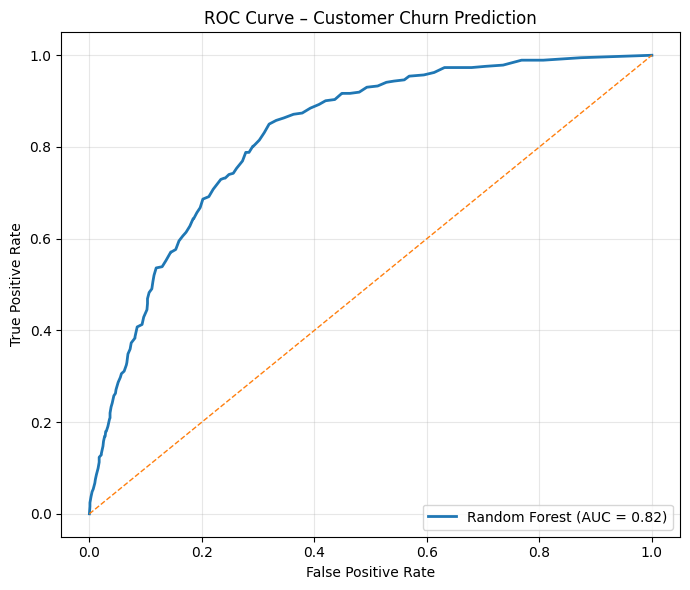

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Customer Churn Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
